In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import argparse
import warnings
from MisTIC.mistic_class import mistic
import numpy as np
import os
import gc
import pandas as pd
import geopandas as gpd

In [1]:
CELL_META_FILE = '../data/merscope_hcc1/cell_meta_subset.csv'
CELL_BOUNDARY_FILE = '../data/merscope_hcc1/cell_boundary_polygons_subset.parquet'

TX_INTERMEDIATE = '../data/merscope_hcc1/intermediates/transcript_meta.csv'
CELL_META_INTERMEDIATE = '../data/merscope_hcc1/intermediates/cell_meta.csv'
CELL_BOUNDARY_INTERMEDIATE = '../data/merscope_hcc1/intermediates/cell_boundaries.parquet'
COUNTS_FILE_INTERMEDIATE = '../data/merscope_hcc1/intermediates/counts_by_genes.csv'

# Alternative simulation MisTIC runs

In [ ]:
def prepare_inputs(
    tx_infile, cell_meta_infile, cell_boundary_infile,
    tx_outfile=TX_INTERMEDIATE, cell_meta_outfile=CELL_META_INTERMEDIATE, 
    cell_boundaries_outfile=CELL_BOUNDARY_INTERMEDIATE, counts_outfile=COUNTS_FILE_INTERMEDIATE,
    test=False
):
    detected_transcripts = pd.read_csv(tx_infile).rename(columns={'Unnamed: 0': ''})
    cell_metadata = pd.read_csv(cell_meta_infile).rename(columns={'cell': 'cell_id'})
    cell_boundaries = gpd.read_parquet(cell_boundary_infile).rename(columns={'cell': 'cell_id'})

    if test:
        cell_metadata = cell_metadata[(cell_metadata['center_x'] < 2000) & (cell_metadata['center_y'] > 6000)]
        detected_transcripts = detected_transcripts[detected_transcripts['cell_id'].isin(cell_metadata['cell_id'].tolist())]
        cell_boundaries = cell_boundaries[cell_boundaries['cell_id'].isin(cell_metadata['cell_id'].tolist())]
    
    counts_df = (detected_transcripts.groupby(['cell_id', 'gene']).size().unstack(fill_value=0))
    counts_df = counts_df.astype(int)
    counts_df.to_csv(counts_outfile)
    detected_transcripts.to_csv(tx_outfile, index=False)
    cell_metadata.to_csv(cell_meta_outfile, index=False)
    cell_boundaries.to_parquet(cell_boundaries_outfile, index=False)
    return counts_outfile, tx_outfile, cell_meta_outfile, cell_boundaries_outfile

In [ ]:
TX_FILE = '../data/merscope_hcc1/synthetic_tx05_doublet0.05_transcript_meta.csv'

counts_outfile, tx_outfile, cell_meta_outfile, cell_boundaries_outfile = prepare_inputs(TX_FILE, CELL_META_FILE, CELL_BOUNDARY_FILE, test=False)

patch_size_pcts = 0.1
output_folder = '../data/normal_mistic/tx05_low_doublet/'
model_name = f'tx05_low_doublet'

# initialize
m = mistic(
    cell_centroid_x_col='center_x',
    cell_centroid_y_col='center_y',
    celltype_col="cell_type",
    tx_x_col='x',
    tx_y_col='y',
    gene_col='gene',
    cell_col='cell_id'
)
# import data
m.import_data(
    cell_by_gene_counts=COUNTS_FILE_INTERMEDIATE,
    cell_metadata=CELL_META_INTERMEDIATE,
    cell_boundary_polygons=CELL_BOUNDARY_INTERMEDIATE,
    detected_transcripts=TX_INTERMEDIATE
)
# set batches
m.patchfy_data(percent_cell_per_patch=patch_size_pcts)
# initialize model
m.initialize_parameters()
gc.collect()
# train model
m.training_loop(n_epochs=20)
gc.collect()
# save model before correction
m.save_model(
    dir_name=output_folder,
    model_name=model_name,
    save_correction_result=False
)
# perform tx corrections
m.compute_reassign_probs()
m.correct_tx(
    reassign_threshold_grid=np.arange(start=0.1, stop=0.6, step=0.1),
    remove_threshold_grid=np.arange(start=0, stop=0.4, step=0.1),
    choice_type="best"
)
gc.collect()
m.save_model(
    dir_name=output_folder,
    model_name=model_name,
    save_correction_result=True
)

In [ ]:
TX_FILE = '../data/merscope_hcc1/synthetic_tx05_doublet0.95_transcript_meta.csv'

counts_outfile, tx_outfile, cell_meta_outfile, cell_boundaries_outfile = prepare_inputs(TX_FILE, CELL_META_FILE, CELL_BOUNDARY_FILE, test=False)

patch_size_pcts = 0.1
output_folder = '../data/normal_mistic/tx05_high_doublet/'
model_name = f'tx05_high_doublet'

# initialize
m = mistic(
    cell_centroid_x_col='center_x',
    cell_centroid_y_col='center_y',
    celltype_col="cell_type",
    tx_x_col='x',
    tx_y_col='y',
    gene_col='gene',
    cell_col='cell_id'
)
# import data
m.import_data(
    cell_by_gene_counts=COUNTS_FILE_INTERMEDIATE,
    cell_metadata=CELL_META_INTERMEDIATE,
    cell_boundary_polygons=CELL_BOUNDARY_INTERMEDIATE,
    detected_transcripts=TX_INTERMEDIATE
)
# set batches
m.patchfy_data(percent_cell_per_patch=patch_size_pcts)
# initialize model
m.initialize_parameters()
gc.collect()
# train model
m.training_loop(n_epochs=20)
gc.collect()
# save model before correction
m.save_model(
    dir_name=output_folder,
    model_name=model_name,
    save_correction_result=False
)
# perform tx corrections
m.compute_reassign_probs()
m.correct_tx(
    reassign_threshold_grid=np.arange(start=0.1, stop=0.6, step=0.1),
    remove_threshold_grid=np.arange(start=0, stop=0.4, step=0.1),
    choice_type="best"
)
gc.collect()
m.save_model(
    dir_name=output_folder,
    model_name=model_name,
    save_correction_result=True
)

# Parse log files for elapsed time

In [3]:
LOGS_DIR = '../data/logs'
script_mapping = {
    0.01: 'slurm-13155257.out',
    0.05: 'slurm-13158131.out',
    0.1: 'slurm-13158139.out',
    0.15: 'slurm-13158141.out',
    0.2: 'slurm-13158145.out'
}

In [34]:
def parse_elapsed_times(log_file_path):
    # Matches patterns like [34:46<00:00, ...]
    time_pattern = re.compile(r"\[(\d+):(\d+)<")
    progress_pattern = re.compile(r"(\d+)/(\d+)")
    train_line = re.compile(r'.*(neighbor\d+).*(\d+)/(\d+).*\[(\d+):(\d+)<')

    total_seconds = 0

    lines_with_time = []
    with open(log_file_path, "r") as f:
        for line in f:
            match_time = time_pattern.search(line)
            match_progress_bar = progress_pattern.search(line)
            if match_time and match_progress_bar:
                total_steps = int(match_progress_bar.group(2))
                end_progress_pattern = re.compile(f"{total_steps}/{total_steps}")
                match_end = end_progress_pattern.search(line)
                if match_end:
                    lines_with_time.append(line)

    time_df = {'line': [], 'neighbor': [], 'n_steps': [], 'elapsed_min': [], 'elapsed_sec': []}
    for l in lines_with_time:
        train_match = train_line.search(l)
        if train_match:
            neighbor = train_match.group(1)
            total_steps = int(train_match.group(2))
            elapsed_min = int(train_match.group(4))
            elapsed_sec = int(train_match.group(5))

            time_df['line'].append(l)
            time_df['neighbor'].append(neighbor)
            time_df['n_steps'].append(total_steps)
            time_df['elapsed_min'].append(elapsed_min)
            time_df['elapsed_sec'].append(elapsed_sec)
    time_df = pd.DataFrame.from_dict(time_df)
    time_df = time_df.loc[(time_df.shift() == time_df)[['neighbor', 'n_steps']].all(axis=1), :]
    return time_df

In [50]:
patch_times = {'patch_pct': [], 'n_epochs': [], 'training_total_sec': []}
for patch_pct in script_mapping:
    time_lines = parse_elapsed_times(os.path.join(LOGS_DIR, script_mapping[patch_pct]))
    n_epochs = time_lines['neighbor'].value_counts().max()
    elapsed_sec = (time_lines['elapsed_min'].sum() * 60) + time_lines['elapsed_sec'].sum()

    patch_times['patch_pct'].append(patch_pct)
    patch_times['n_epochs'].append(n_epochs)
    patch_times['training_total_sec'].append(elapsed_sec)
patch_times = pd.DataFrame.from_dict(patch_times)
patch_times.to_csv('../data/logs/training_time.csv', index=False)    

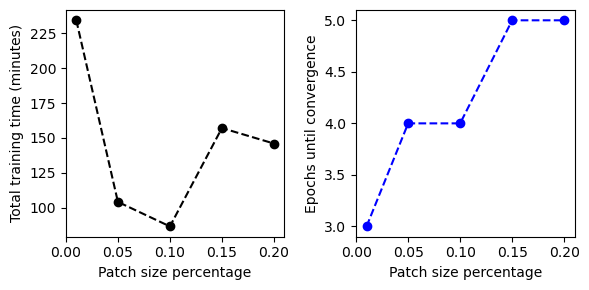

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
patch_times = pd.read_csv('../data/logs/training_time.csv')

fig, axs = plt.subplots(1, 2, figsize=(6, 3))
axs[0].plot(patch_times['patch_pct'], patch_times['training_total_sec'] / 60, '--ok')
axs[0].set_xlim(0, 0.21)
axs[0].set_xlabel('Patch size percentage')
axs[0].set_ylabel('Total training time (minutes)')

axs[1].plot(patch_times['patch_pct'], patch_times['n_epochs'], '--ob')
axs[1].set_xlim(0, 0.21)
axs[1].set_xlabel('Patch size percentage')
axs[1].set_ylabel('Epochs until convergence')
plt.tight_layout()
plt.savefig('../results/patch_size_training_time.png', bbox_inches='tight')